In [338]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import seaborn as sns
sns.set_style("whitegrid")
import pandas as pd
from adjustText import adjust_text
import sys

SUPER RESOLUTION

In [339]:
pwd

'/work/FAC/FGSE/IDYST/tbeucler/downscaling/sasthana/Downscaling/Processing_and_Analysis_Scripts/Analysis/Paper_Stats'

Masks : necessary for metrics 

In [340]:
#Making Swiss LR mask
ds_HR= xr.open_dataset('../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step1_latlon.nc')["TabsD"]
Swiss_Mask_HR= ds_HR.isel(time=0).notnull()

Swiss_Mask_HR.to_netcdf('../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/Swiss_Mask_HR.nc')

In [341]:
Swiss_Mask_HR.shape

(240, 370)

In [342]:
#Making Swiss LR mask
ds_LR= xr.open_dataset('../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step2_coarse.nc')["TabsD"]

In [343]:
Swiss_Mask_LR= ds_LR.isel(time=0).notnull()
Swiss_Mask_LR.to_netcdf('../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/Swiss_Mask_LR.nc')

In [344]:
Swiss_Mask_LR.shape

(20, 30)

The same mask applied to all analysis files $

SR deterministic baselines

In [345]:
pr_val = xr.open_dataset("../../data_1971_2023/HR_files_full/RhiresD_1971_2023.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
temp_val = xr.open_dataset("../../data_1971_2023/HR_files_full/TabsD_1971_2023.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [346]:
pr_val = pr_val.where(Swiss_Mask_HR)

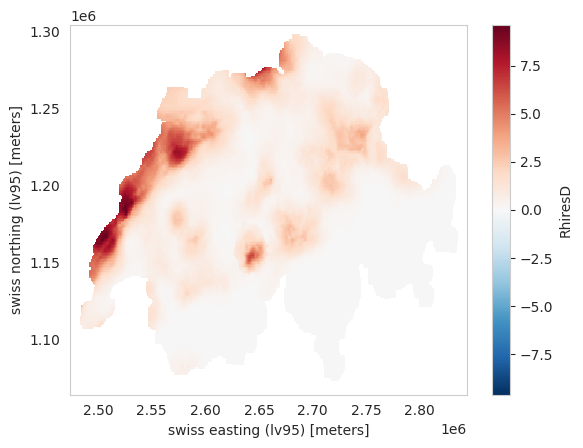

In [347]:
pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

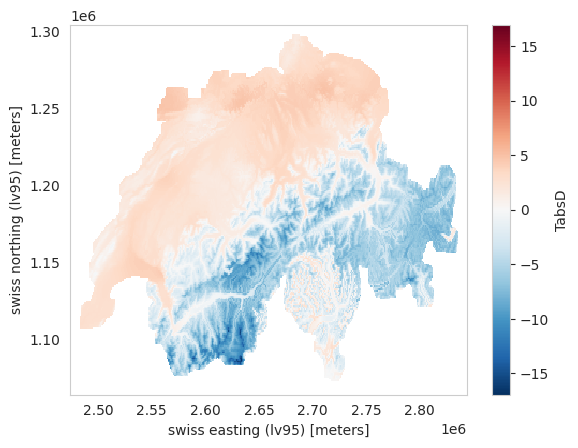

In [348]:
temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Coarse baseline (val set evaluation)

In [349]:
coarse_pr_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/RhiresD_step2_coarse.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
coarse_temp_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step2_coarse.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [350]:
coarse_pr_val = coarse_pr_val.where(Swiss_Mask_LR)
coarse_temp_val = coarse_temp_val.where(Swiss_Mask_LR)

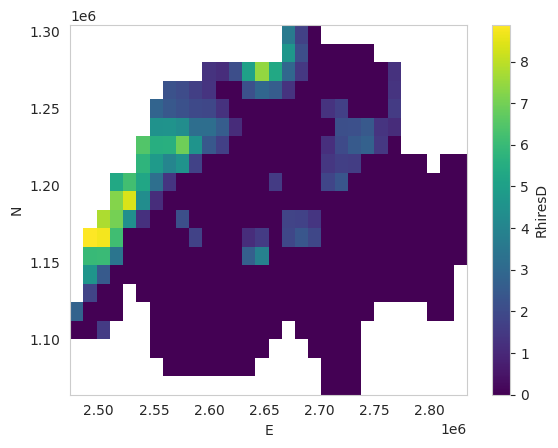

In [351]:
coarse_pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

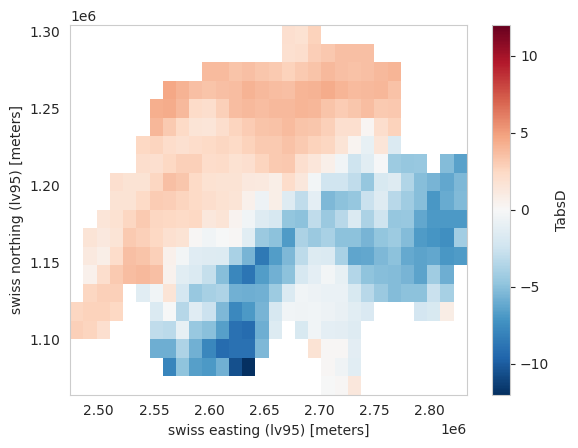

In [352]:
coarse_temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Bicubic baselines

In [353]:
bicubic_pr_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/RhiresD_step3_interp_bicubic.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
bicubic_temp_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step3_interp_bicubic.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [354]:
bicubic_pr_val = bicubic_pr_val.where(Swiss_Mask_HR)
bicubic_temp_val = bicubic_temp_val.where(Swiss_Mask_HR)

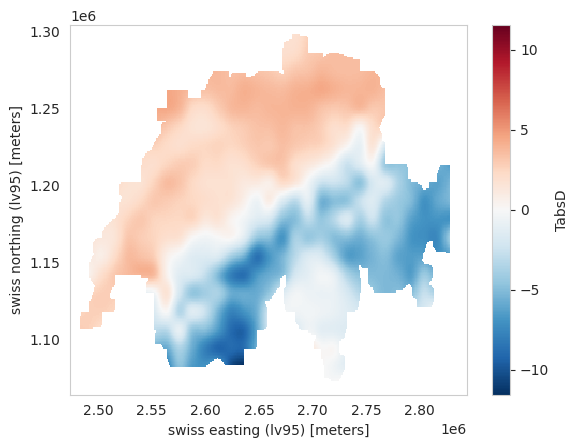

In [355]:
bicubic_temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

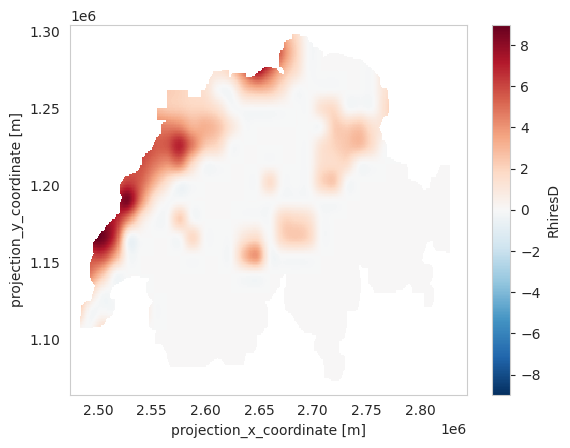

In [356]:
bicubic_pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Bilinear baselines

In [357]:
bilinear_pr_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/RhiresD_step3_interp_bilinear.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
bilinear_temp_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step3_interp_bilinear.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [358]:
bilinear_pr_val= bilinear_pr_val.where(Swiss_Mask_HR)
bilinear_temp_val= bilinear_temp_val.where(Swiss_Mask_HR)

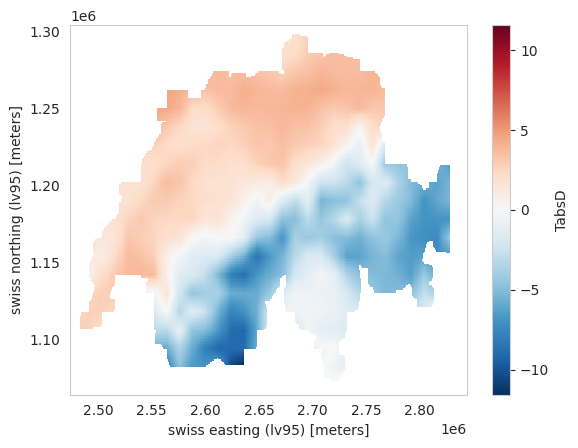

In [359]:
bilinear_temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

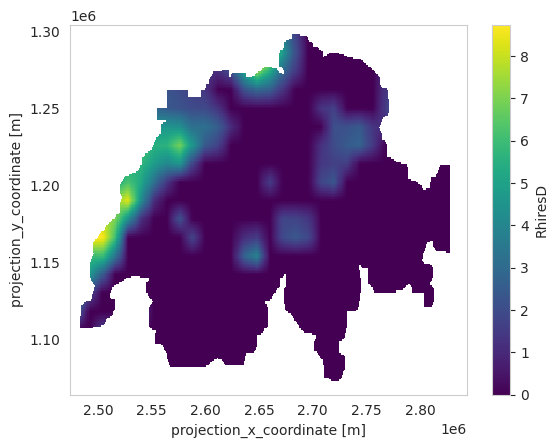

In [360]:
bilinear_pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

UNet baselines : bilinear and bicubic

In [361]:
bilinear_unet_precip=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BILINEAR_unet_downscaled_val_set.nc")["precip"].sel(time=slice("2005-01-01", "2014-12-31"))
bilinear_unet_temp=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BILINEAR_unet_downscaled_val_set.nc")["temp"].sel(time=slice("2005-01-01", "2014-12-31"))

In [362]:
bicubic_unet_precip=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BICUBIC_unet_downscaled_val_set.nc")["precip"].sel(time=slice("2005-01-01", "2014-12-31"))
bicubic_unet_temp=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BICUBIC_unet_downscaled_val_set.nc")["temp"].sel(time=slice("2005-01-01", "2014-12-31"))

In [363]:
bilinear_unet_precip = bilinear_unet_precip.where(Swiss_Mask_HR)
bilinear_unet_temp = bilinear_unet_temp.where(Swiss_Mask_HR)

In [364]:
bicubic_unet_precip = bicubic_unet_precip.where(Swiss_Mask_HR)
bicubic_unet_temp = bicubic_unet_temp.where(Swiss_Mask_HR)

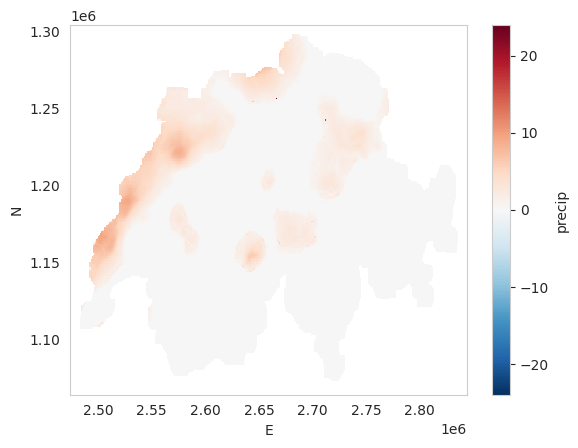

In [365]:
bilinear_unet_precip.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

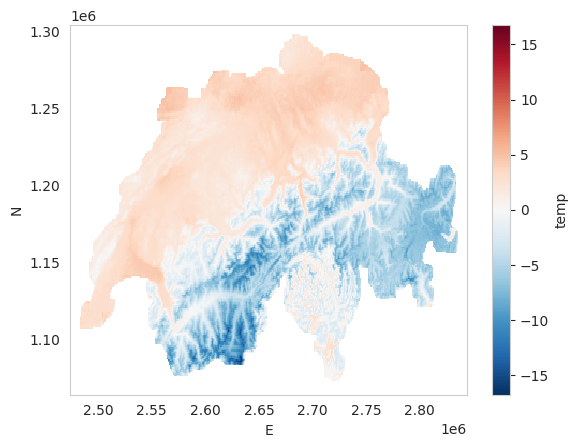

In [366]:
bilinear_unet_temp.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Deterministic UNet baseline

Metrics : MAE, SSIM, PSNR

In [367]:
from mae import spatial_mean_ts, mae

In [368]:
pr_val_ts = spatial_mean_ts(pr_val)
temp_val_ts = spatial_mean_ts(temp_val)

coarse_pr_ts = spatial_mean_ts(coarse_pr_val)
coarse_temp_ts = spatial_mean_ts(coarse_temp_val)

bicubic_pr_ts = spatial_mean_ts(bicubic_pr_val)
bicubic_temp_ts = spatial_mean_ts(bicubic_temp_val)

bilinear_pr_ts = spatial_mean_ts(bilinear_pr_val)
bilinear_temp_ts = spatial_mean_ts(bilinear_temp_val)

In [369]:
pr_coarse_mae = mae(coarse_pr_ts, pr_val_ts)
temp_coarse_mae = mae(coarse_temp_ts, temp_val_ts)

pr_bicubic_mae = mae(bicubic_pr_ts, pr_val_ts)
temp_bicubic_mae = mae(bicubic_temp_ts, temp_val_ts)

pr_bilinear_mae = mae(bilinear_pr_ts, pr_val_ts)
temp_bilinear_mae = mae(bilinear_temp_ts, temp_val_ts)

In [370]:
unet_bilinear_pr_mae = mae(spatial_mean_ts(bilinear_unet_precip), pr_val_ts)
unet_bilinear_temp_mae = mae(spatial_mean_ts(bilinear_unet_temp), temp_val_ts)

unet_bicubic_pr_mae = mae(spatial_mean_ts(bicubic_unet_precip), pr_val_ts)
unet_bicubic_temp_mae = mae(spatial_mean_ts(bicubic_unet_temp), temp_val_ts)

In [371]:
import sys

In [372]:
from ssim_precip import framewise_ssim as ssim_precip
from ssim_temp import framewise_ssim as ssim_temp

Mean SSIM across all timesteps for val .. set. 

In [373]:
pr_bicubic_ssim = ssim_precip(pr_val, bicubic_pr_val)
pr_bilinear_ssim = ssim_precip(pr_val, bilinear_pr_val)
pr_unet_bilinear_ssim = ssim_precip(pr_val, bilinear_unet_precip)
pr_unet_bicubic_ssim = ssim_precip(pr_val, bicubic_unet_precip)

/work/FAC/FGSE/IDYST/tbeucler/downscaling/sasthana/Downscaling/Downscaling_Models/.micromamba/envs/diffscaler/lib/python3.9/site-packages/skimage/metrics/_structural_similarity.py:230: RuntimeWarning: invalid value encountered in divide
  S = (A1 * A2) / D


In [ ]:
temp_bicubic_ssim = ssim_temp(temp_val, bicubic_temp_val)
temp_bilinear_ssim = ssim_temp(temp_val, bilinear_temp_val)
temp_unet_bilinear_ssim = ssim_temp(temp_val, bilinear_unet_temp)
temp_unet_bicubic_ssim = ssim_temp(temp_val, bicubic_unet_temp)

In [ ]:
from psnr import psnr

In [ ]:
results = pd.DataFrame({
    "Val Set": ["Coarse", "Bic", "Bil", "UNetBil", "UNetBic"],
    "1-Precipitation SSIM": [np.nan, 1- float(pr_bicubic_ssim), 1-float(pr_bilinear_ssim), 1-float(pr_unet_bilinear_ssim), 1-float(pr_unet_bicubic_ssim)],
    "1-Temperature SSIM": [np.nan, 1-float(temp_bicubic_ssim), 1-float(temp_bilinear_ssim), 1-float(temp_unet_bilinear_ssim), 1-float(temp_unet_bicubic_ssim)],
    "Pr MAE": [pr_coarse_mae, pr_bicubic_mae, pr_bilinear_mae, unet_bilinear_pr_mae, unet_bicubic_pr_mae],
    "Temp MAE": [temp_coarse_mae, temp_bicubic_mae, temp_bilinear_mae, unet_bilinear_temp_mae, unet_bicubic_temp_mae],
    "PSNR Precipitation": [np.nan, psnr(bicubic_pr_val, pr_val), psnr(bilinear_pr_val, pr_val), psnr(bilinear_unet_precip, pr_val), psnr(bicubic_unet_precip, pr_val)],
    "PSNR Temperature": [np.nan, psnr(bicubic_temp_val, temp_val), psnr(bilinear_temp_val, temp_val), psnr(bilinear_unet_temp, temp_val), psnr(bicubic_unet_temp, temp_val)],
})


print(results)

   Val Set  1-Precipitation SSIM  1-Temperature SSIM    Pr MAE  Temp MAE  \
0   Coarse                   NaN                 NaN  0.213174  0.074883   
1      Bic              0.197672            0.266922  0.091386  0.029870   
2      Bil              0.189794            0.274434  0.088413  0.025715   
3  UNetBil              0.177862            0.022354  0.157218  0.069926   
4  UNetBic              0.179751            0.017812  0.218947  0.031594   

   PSNR Precipitation  PSNR Temperature  
0                 NaN               NaN  
1           48.595450         23.864498  
2           47.561917         23.612800  
3           50.971883         38.161653  
4           50.682793         39.441862  
